In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

# 1. Load the Kaggle wine reviews dataset
df = pd.read_csv("winemag-data-130k-v2.csv")

# Keep columns relevant to modeling (Select features and target)
cols = ["points", "price", "country", "province", "variety", "winery"]
data = df[cols].dropna(subset=["points", "price"]).copy()

print("Rows after dropping missing target/price:", data.shape[0])
print(data.describe(include="all"))

Rows after dropping missing target/price: 120975
               points          price country    province     variety  \
count   120975.000000  120975.000000  120916      120916      120974   
unique            NaN            NaN      42         422         697   
top               NaN            NaN      US  California  Pinot Noir   
freq              NaN            NaN   54265       36104       12787   
mean        88.421881      35.363389     NaN         NaN         NaN   
std          3.044508      41.022218     NaN         NaN         NaN   
min         80.000000       4.000000     NaN         NaN         NaN   
25%         86.000000      17.000000     NaN         NaN         NaN   
50%         88.000000      25.000000     NaN         NaN         NaN   
75%         91.000000      42.000000     NaN         NaN         NaN   
max        100.000000    3300.000000     NaN         NaN         NaN   

            winery  
count       120975  
unique       15855  
top     Testarossa  
fr

In [3]:
# Features and Target
X_full = data.drop(columns=["points"])
y_full = data["points"]

numeric_features = ["price"]
categorical_features = ["country", "province", "variety", "winery"]

# Numeric Transformer: Median Imputation + Log1p Transform + Standardization
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(func=np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

# Categorical Transformer: Mode Imputation + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

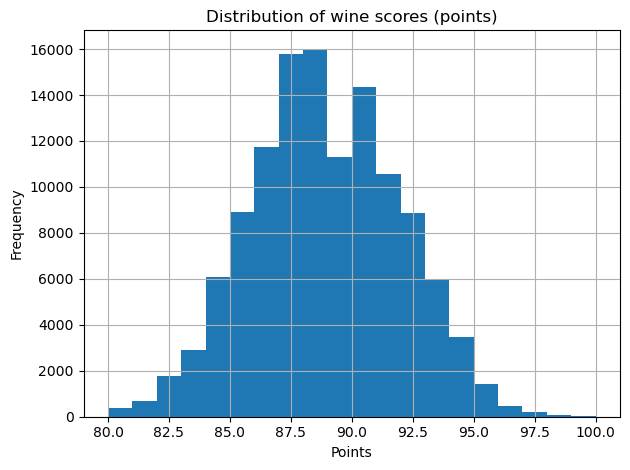

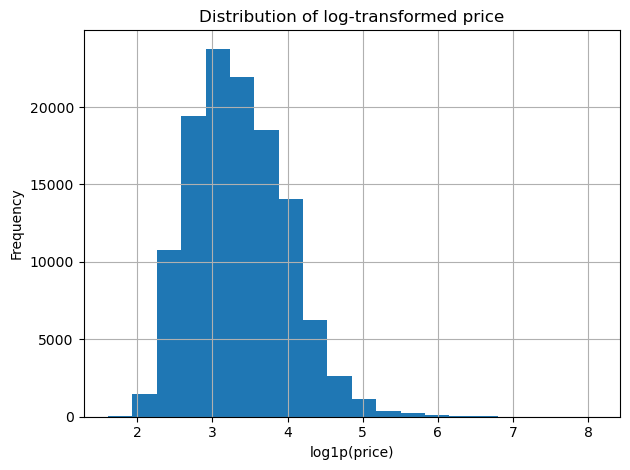

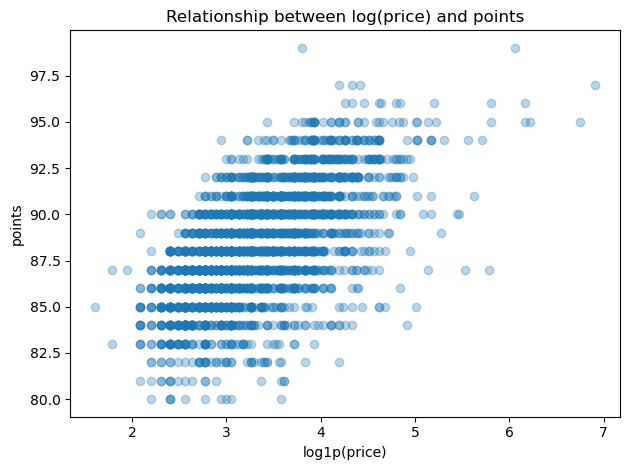

In [5]:
# Figure 1: Histogram of points
plt.figure()
data["points"].hist(bins=20)
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.title("Distribution of wine scores (points)")
plt.tight_layout()
plt.show()

# Figure 2: Histogram of log(price)
plt.figure()
np.log1p(data["price"]).hist(bins=20)
plt.xlabel("log1p(price)")
plt.ylabel("Frequency")
plt.title("Distribution of log-transformed price")
plt.tight_layout()
plt.show()

# Figure 3: Scatter plot of log(price) vs points (sampled to avoid overplotting)
sample = data.sample(3000, random_state=0)
plt.figure()
plt.scatter(np.log1p(sample["price"]), sample["points"], alpha=0.3)
plt.xlabel("log1p(price)")
plt.ylabel("points")
plt.title("Relationship between log(price) and points")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import r2_score

def evaluate_model(name, model, X, y, cv):
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    
    scoring = {
        "mae": make_scorer(mean_absolute_error, greater_is_better=False),
        "mse": make_scorer(mean_squared_error, greater_is_better=False),
        "r2": "r2"
    }
    
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    mae = -scores["test_mae"].mean()
    rmse = np.sqrt(-scores["test_mse"].mean())
    r2 = scores["test_r2"].mean()
    sd_mae = scores["test_mae"].std()
    sd_r2 = scores["test_r2"].std()
    
    print(f"{name:15s} | MAE={mae:.3f} (sd={sd_mae:.3f}) | "
          f"RMSE={rmse:.3f} | R2={r2:.3f} (sd={sd_r2:.3f})")
    
    return dict(name=name, mae=mae, rmse=rmse, r2=r2,
                sd_mae=sd_mae, sd_r2=sd_r2)

# Sample 1500 rows for CV comparison across all models
data_small = data.sample(10000, random_state=0)
X = data_small.drop(columns=["points"])
y = data_small["points"]

cv = KFold(n_splits=3, shuffle=True, random_state=42)

results = []
results.append(evaluate_model("BaselineMean",
                              DummyRegressor(strategy="mean"), X, y, cv))
results.append(evaluate_model("KNN_k5",
                              KNeighborsRegressor(n_neighbors=5), X, y, cv))
results.append(evaluate_model("RandomForest",
                              RandomForestRegressor(
                                  n_estimators=50,
                                  max_depth=12,
                                  random_state=42,
                                  n_jobs=-1
                              ), X, y, cv))

results_df = pd.DataFrame(results)
print(results_df)

BaselineMean    | MAE=2.475 (sd=0.007) | RMSE=3.024 | R2=-0.001 (sd=0.001)
KNN_k5          | MAE=1.910 (sd=0.013) | RMSE=2.425 | R2=0.356 (sd=0.006)
RandomForest    | MAE=1.839 (sd=0.015) | RMSE=2.316 | R2=0.413 (sd=0.014)
           name       mae      rmse        r2    sd_mae     sd_r2
0  BaselineMean  2.475221  3.024012 -0.001464  0.007036  0.001038
1        KNN_k5  1.910480  2.424817  0.356077  0.012541  0.006429
2  RandomForest  1.839238  2.315908  0.412601  0.014811  0.013634


In [9]:
from sklearn.metrics import r2_score

def evaluate_model(name, model, X, y, cv):
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    
    scoring = {
        "mae": make_scorer(mean_absolute_error, greater_is_better=False),
        "mse": make_scorer(mean_squared_error, greater_is_better=False),
        "r2": "r2"
    }
    
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    mae = -scores["test_mae"].mean()
    rmse = np.sqrt(-scores["test_mse"].mean())
    r2 = scores["test_r2"].mean()
    sd_mae = scores["test_mae"].std()
    sd_r2 = scores["test_r2"].std()
    
    print(f"{name:15s} | MAE={mae:.3f} (sd={sd_mae:.3f}) | "
          f"RMSE={rmse:.3f} | R2={r2:.3f} (sd={sd_r2:.3f})")
    
    return dict(name=name, mae=mae, rmse=rmse, r2=r2,
                sd_mae=sd_mae, sd_r2=sd_r2)

# Sample 1500 rows for CV comparison across all models
data_small = data.sample(10000, random_state=0)
X = data_small.drop(columns=["points"])
y = data_small["points"]

cv = KFold(n_splits=3, shuffle=True, random_state=42)

results = []
results.append(evaluate_model("BaselineMean",
                              DummyRegressor(strategy="mean"), X, y, cv))
results.append(evaluate_model("KNN_k5",
                              KNeighborsRegressor(n_neighbors=5), X, y, cv))
results.append(evaluate_model("RandomForest",
                              RandomForestRegressor(
                                  n_estimators=50,
                                  max_depth=12,
                                  random_state=42,
                                  n_jobs=-1
                              ), X, y, cv))

results_df = pd.DataFrame(results)
print(results_df)

BaselineMean    | MAE=2.449 (sd=0.044) | RMSE=2.999 | R2=-0.000 (sd=0.000)
KNN_k5          | MAE=1.981 (sd=0.017) | RMSE=2.515 | R2=0.296 (sd=0.015)
RandomForest    | MAE=1.872 (sd=0.042) | RMSE=2.389 | R2=0.365 (sd=0.030)
           name       mae      rmse        r2    sd_mae     sd_r2
0  BaselineMean  2.448771  2.998643 -0.000444  0.043610  0.000318
1        KNN_k5  1.980533  2.514767  0.296496  0.016896  0.014879
2  RandomForest  1.872414  2.389229  0.364610  0.041592  0.030120


In [27]:
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

def evaluate_model(name, model, X, y, cv):
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    
    scoring = {
        "mae": make_scorer(mean_absolute_error, greater_is_better=False),
        "mse": make_scorer(mean_squared_error, greater_is_better=False),
        "r2": "r2"
    }
    
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=scoring,
        return_train_score=True,   # Key: Retrieve training scores to check for overfitting
        n_jobs=-1
    )
    
    mae = -scores["test_mae"].mean()
    rmse = np.sqrt(-scores["test_mse"].mean())
    r2_test = scores["test_r2"].mean()
    r2_train = scores["train_r2"].mean()
    
    sd_mae = scores["test_mae"].std()
    sd_r2 = scores["test_r2"].std()
    
    print(f"{name:15s} | MAE={mae:.3f} (sd={sd_mae:.3f}) | "
          f"RMSE={rmse:.3f} | R2_test={r2_test:.3f} | R2_train={r2_train:.3f}")
    
    return dict(
        name=name,
        mae=mae,
        rmse=rmse,
        r2=r2_test,
        r2_train=r2_train,
        sd_mae=sd_mae,
        sd_r2=sd_r2
    )

# Re-run the three models
results = []
results.append(evaluate_model("BaselineMean",
                              DummyRegressor(strategy="mean"), X, y, cv))
results.append(evaluate_model("KNN_k5",
                              KNeighborsRegressor(n_neighbors=5), X, y, cv))
results.append(evaluate_model("RandomForest",
                              RandomForestRegressor(
                                  n_estimators=50,
                                  max_depth=12,
                                  random_state=42,
                                  n_jobs=-1
                              ), X, y, cv))

results_df = pd.DataFrame(results)
print(results_df)

BaselineMean    | MAE=2.475 (sd=0.007) | RMSE=3.024 | R2_test=-0.001 | R2_train=0.000
KNN_k5          | MAE=1.910 (sd=0.013) | RMSE=2.425 | R2_test=0.356 | R2_train=0.582
RandomForest    | MAE=1.839 (sd=0.015) | RMSE=2.316 | R2_test=0.413 | R2_train=0.526
           name       mae      rmse        r2  r2_train    sd_mae     sd_r2
0  BaselineMean  2.475221  3.024012 -0.001464  0.000000  0.007036  0.001038
1        KNN_k5  1.910480  2.424817  0.356077  0.582095  0.012541  0.006429
2  RandomForest  1.839238  2.315908  0.412601  0.525909  0.014811  0.013634


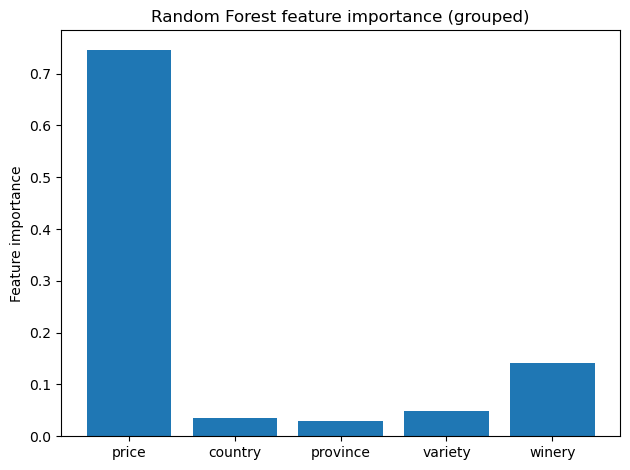

In [29]:
# Fit Random Forest pipeline
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipe.fit(X, y)
rf_model = rf_pipe.named_steps["model"]

importances = rf_model.feature_importances_

# Get the number of categories after one-hot encoding
cat_imputer = SimpleImputer(strategy="most_frequent")
X_cat = cat_imputer.fit_transform(X[categorical_features])

ohe = OneHotEncoder(handle_unknown="ignore")
ohe.fit(X_cat)
lens = [len(cats) for cats in ohe.categories_]

# Aggregate importances back to the original feature groups
price_importance = importances[0]
offset = 1
group_importances = {}
start = offset
for name, L in zip(categorical_features, lens):
    group_importances[name] = importances[start:start+L].sum()
    start += L

groups = ["price"] + categorical_features
values = [price_importance] + [group_importances[f] for f in categorical_features]

plt.figure()
plt.bar(groups, values)
plt.ylabel("Feature importance")
plt.title("Random Forest feature importance (grouped)")
plt.tight_layout()
plt.show()

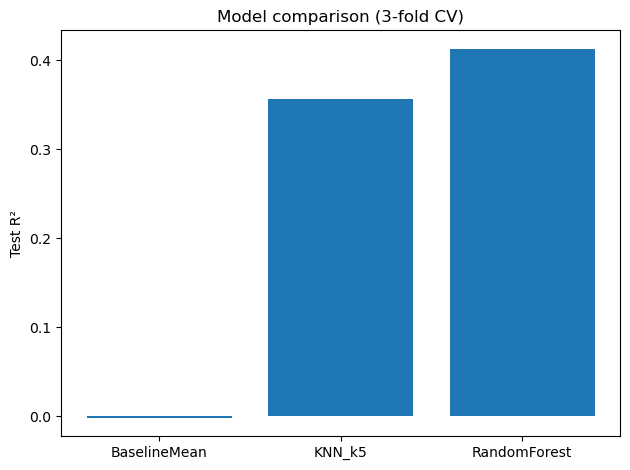

In [31]:
# Model Performance Comparison: Using test R²
plt.figure()
plt.bar(results_df["name"], results_df["r2"])
plt.ylabel("Test R²")
plt.title("Model comparison (3-fold CV)")
plt.tight_layout()
plt.show()

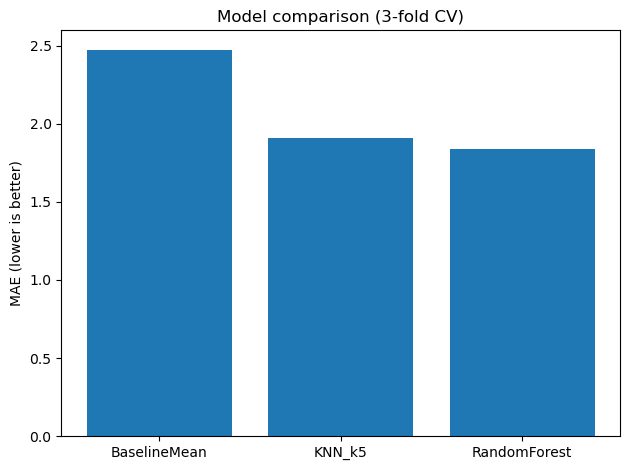

In [33]:
plt.figure()
plt.bar(results_df["name"], results_df["mae"])
plt.ylabel("MAE (lower is better)")
plt.title("Model comparison (3-fold CV)")
plt.tight_layout()
plt.show()

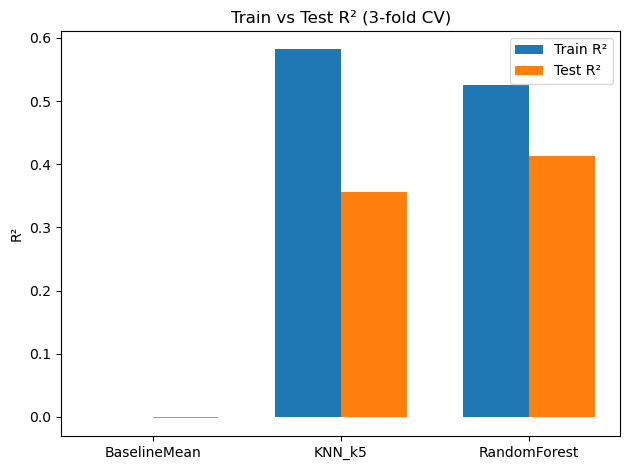

In [35]:
models = results_df["name"].tolist()
train_r2 = results_df["r2_train"].tolist()
test_r2 = results_df["r2"].tolist()

x = np.arange(len(models))  
width = 0.35

plt.figure()
plt.bar(x - width/2, train_r2, width, label="Train R²")
plt.bar(x + width/2, test_r2, width, label="Test R²")
plt.xticks(x, models)
plt.ylabel("R²")
plt.title("Train vs Test R² (3-fold CV)")
plt.legend()
plt.tight_layout()
plt.show()